# Motion Code Analysis for T2M Training

이 노트북은 VQ-VAE에서 생성된 motion codes를 분석합니다.

## 분석 항목
1. **기본 통계**: 시퀀스 길이, 데이터 수
2. **Codebook Utilization**: 사용되는 code 비율, dead codes
3. **Code 분포**: Train/Dev/Test 간 분포 비교
4. **Split 간 유사성**: KL/JS divergence
5. **부위별 분석**: Body/LHand/RHand 각각의 특성
6. **시퀀스 패턴**: Bigram, 연속 반복 패턴
7. **부위 간 상관관계**: Body-Hand 동시 발생

In [ ]:
import os
import numpy as np
import pandas as pd
from glob import glob
from collections import Counter, defaultdict
from scipy.stats import entropy
from scipy.spatial.distance import jensenshannon
import warnings
warnings.filterwarnings('ignore')

# matplotlib 설정 (호환성 문제 해결)
import matplotlib
import matplotlib.pyplot as plt

# 스타일 설정 (호환성 있는 방식)
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    try:
        plt.style.use('seaborn-whitegrid')
    except:
        pass  # 기본 스타일 사용

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
# inline display for jupyter
%matplotlib inline

print("Libraries loaded!")
print(f"Matplotlib version: {matplotlib.__version__}")

Libraries loaded!
Matplotlib version: 3.10.8


## 1. 데이터 로드

In [2]:
# ============================================
# 설정: 경로와 codebook 크기
# ============================================
MOTION_CODE_DIR = "/home/user/Projects/Data/new_phoenix/motion_codes_decouple"  # motion codes 저장 경로
BODY_CODEBOOK_SIZE = 96
LHAND_CODEBOOK_SIZE = 192
RHAND_CODEBOOK_SIZE = 192

# 경로 확인
print(f"Motion code directory: {os.path.abspath(MOTION_CODE_DIR)}")
print(f"Exists: {os.path.exists(MOTION_CODE_DIR)}")

if os.path.exists(MOTION_CODE_DIR):
    for split in ['train', 'dev', 'test']:
        split_dir = os.path.join(MOTION_CODE_DIR, split)
        if os.path.exists(split_dir):
            files = glob(os.path.join(split_dir, '*.npy'))
            print(f"  {split}: {len(files)} files")

Motion code directory: /home/user/Projects/Data/new_phoenix/motion_codes_decouple
Exists: True
  train: 7096 files
  dev: 519 files
  test: 642 files


In [3]:
def load_motion_codes(base_dir, split):
    """
    Load all motion codes for a split.
    
    Returns:
        data: list of dicts with 'name', 'body', 'lhand', 'rhand', 'length'
    """
    split_dir = os.path.join(base_dir, split)
    if not os.path.exists(split_dir):
        print(f"Directory not found: {split_dir}")
        return []
    
    files = sorted(glob(os.path.join(split_dir, '*.npy')))
    data = []
    
    for f in files:
        codes = np.load(f)  # Expected shape: (1, T, 3) or (T, 3)
        if codes.ndim == 3:
            codes = codes[0]  # (T, 3)
        
        name = os.path.basename(f).replace('.npy', '')
        data.append({
            'name': name,
            'body': codes[:, 0].astype(int),
            'lhand': codes[:, 1].astype(int),
            'rhand': codes[:, 2].astype(int),
            'length': len(codes)
        })
    
    return data

# Load all splits
train_data = load_motion_codes(MOTION_CODE_DIR, 'train')
dev_data = load_motion_codes(MOTION_CODE_DIR, 'dev')
test_data = load_motion_codes(MOTION_CODE_DIR, 'test')

print(f"\nLoaded data:")
print(f"  Train: {len(train_data)} samples")
print(f"  Dev: {len(dev_data)} samples")
print(f"  Test: {len(test_data)} samples")


Loaded data:
  Train: 7096 samples
  Dev: 519 samples
  Test: 642 samples


In [4]:
# 샘플 데이터 확인
if train_data:
    sample = train_data[0]
    print(f"Sample: {sample['name']}")
    print(f"  Length: {sample['length']}")
    print(f"  Body codes (first 20): {sample['body'][:20]}")
    print(f"  LHand codes (first 20): {sample['lhand'][:20]}")
    print(f"  RHand codes (first 20): {sample['rhand'][:20]}")
    print(f"\n  Body range: [{sample['body'].min()}, {sample['body'].max()}]")
    print(f"  LHand range: [{sample['lhand'].min()}, {sample['lhand'].max()}]")
    print(f"  RHand range: [{sample['rhand'].min()}, {sample['rhand'].max()}]")

Sample: 01April_2010_Thursday_heute-6694
  Length: 13
  Body codes (first 20): [25 74 44 70 32 47 84 92 65 78 38 38 38]
  LHand codes (first 20): [139 167  43  90 172  53 140   9 150   3  36  94  30]
  RHand codes (first 20): [180  93 116 125 124  21 140 120  39 109 152  49 152]

  Body range: [25, 92]
  LHand range: [3, 172]
  RHand range: [21, 180]


## 2. 기본 통계

In [5]:
def compute_basic_stats(data, name):
    """Compute basic statistics for a split."""
    if not data:
        return None
    
    lengths = [d['length'] for d in data]
    
    stats = {
        'split': name,
        'num_samples': len(data),
        'total_frames': sum(lengths),
        'avg_length': np.mean(lengths),
        'std_length': np.std(lengths),
        'min_length': np.min(lengths),
        'max_length': np.max(lengths),
        'median_length': np.median(lengths),
    }
    return stats

# Compute stats
stats_list = []
for data, name in [(train_data, 'train'), (dev_data, 'dev'), (test_data, 'test')]:
    s = compute_basic_stats(data, name)
    if s:
        stats_list.append(s)

stats_df = pd.DataFrame(stats_list)
print("=" * 60)
print("Basic Statistics")
print("=" * 60)
print(stats_df.round(2).to_string())

Basic Statistics
   split  num_samples  total_frames  avg_length  std_length  min_length  max_length  median_length
0  train         7096        204003       28.75       12.33           5          75           28.0
1    dev          519         13759       26.51       11.11           5          68           26.0
2   test          642         15919       24.80       10.43           5          60           24.5


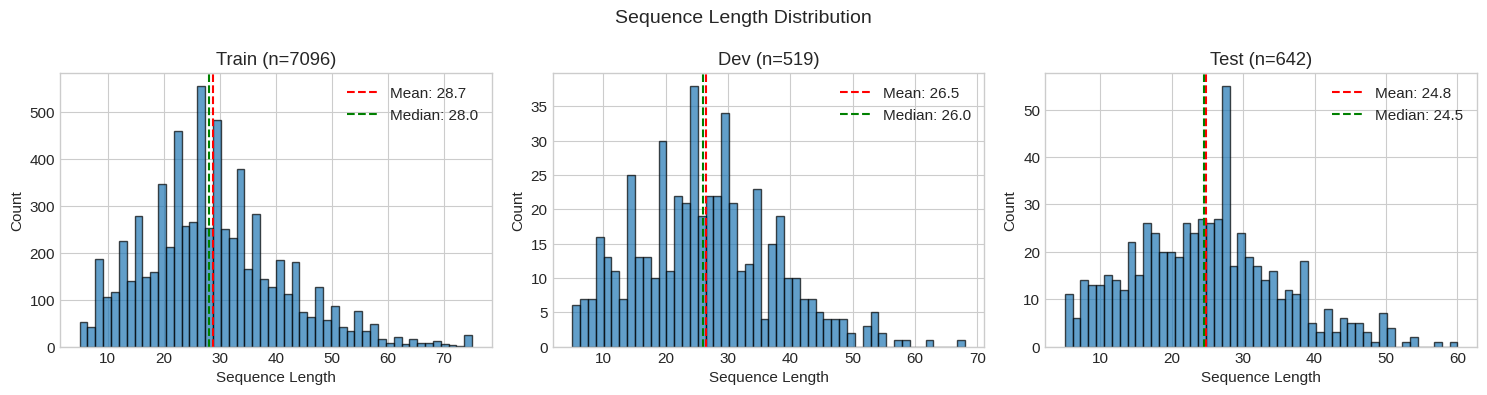

Saved: length_distribution.png


In [6]:
# 시퀀스 길이 분포
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (data, name) in enumerate([(train_data, 'Train'), (dev_data, 'Dev'), (test_data, 'Test')]):
    ax = axes[idx]
    if data:
        lengths = [d['length'] for d in data]
        ax.hist(lengths, bins=50, edgecolor='black', alpha=0.7)
        ax.axvline(np.mean(lengths), color='red', linestyle='--', label=f'Mean: {np.mean(lengths):.1f}')
        ax.axvline(np.median(lengths), color='green', linestyle='--', label=f'Median: {np.median(lengths):.1f}')
        ax.set_xlabel('Sequence Length')
        ax.set_ylabel('Count')
        ax.set_title(f'{name} (n={len(data)})')
        ax.legend()

plt.suptitle('Sequence Length Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('length_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: length_distribution.png")

## 3. Codebook Utilization 분석

- **목표**: 모든 codebook entries가 골고루 사용되는지 확인
- **문제**: Codebook collapse (일부 codes만 과도하게 사용)

In [7]:
def compute_codebook_utilization(data, part, codebook_size):
    """
    Compute codebook utilization statistics.
    """
    if not data:
        return None
    
    # Collect all codes
    all_codes = np.concatenate([d[part] for d in data])
    
    # Count occurrences
    code_counts = Counter(all_codes)
    
    # Used codes
    used_codes = set(code_counts.keys())
    num_used = len(used_codes)
    
    # Dead codes (never used)
    all_possible = set(range(codebook_size))
    dead_codes = all_possible - used_codes
    
    # Frequency distribution
    frequencies = np.array([code_counts.get(i, 0) for i in range(codebook_size)])
    
    # Entropy (higher = more uniform)
    probs = frequencies / frequencies.sum() if frequencies.sum() > 0 else frequencies
    code_entropy = entropy(probs + 1e-10)
    max_entropy = np.log(codebook_size)
    
    return {
        'codebook_size': codebook_size,
        'num_used': num_used,
        'utilization_rate': num_used / codebook_size * 100,
        'num_dead': len(dead_codes),
        'dead_codes': sorted(dead_codes)[:20],
        'total_tokens': len(all_codes),
        'entropy': code_entropy,
        'normalized_entropy': code_entropy / max_entropy * 100,
        'top_10_codes': code_counts.most_common(10),
        'bottom_10_codes': code_counts.most_common()[-10:] if len(code_counts) >= 10 else [],
        'frequencies': frequencies,
    }

# Compute for all parts and splits
utilization = {}
for split_name, data in [('train', train_data), ('dev', dev_data), ('test', test_data)]:
    utilization[split_name] = {}
    for part, size in [('body', BODY_CODEBOOK_SIZE), ('lhand', LHAND_CODEBOOK_SIZE), ('rhand', RHAND_CODEBOOK_SIZE)]:
        utilization[split_name][part] = compute_codebook_utilization(data, part, size)

In [8]:
# Utilization summary table
util_rows = []
for split in ['train', 'dev', 'test']:
    for part in ['body', 'lhand', 'rhand']:
        u = utilization[split][part]
        if u:
            util_rows.append({
                'Split': split,
                'Part': part,
                'Codebook Size': u['codebook_size'],
                'Used Codes': u['num_used'],
                'Utilization (%)': u['utilization_rate'],
                'Dead Codes': u['num_dead'],
                'Norm. Entropy (%)': u['normalized_entropy'],
            })

util_df = pd.DataFrame(util_rows)
print("=" * 70)
print("Codebook Utilization Summary")
print("=" * 70)
print(util_df.round(2).to_string())

Codebook Utilization Summary
   Split   Part  Codebook Size  Used Codes  Utilization (%)  Dead Codes  Norm. Entropy (%)
0  train   body             96          96            100.0           0              98.94
1  train  lhand            192         192            100.0           0              99.28
2  train  rhand            192         192            100.0           0              99.27
3    dev   body             96          96            100.0           0              98.88
4    dev  lhand            192         192            100.0           0              99.05
5    dev  rhand            192         192            100.0           0              99.14
6   test   body             96          96            100.0           0              98.80
7   test  lhand            192         192            100.0           0              99.10
8   test  rhand            192         192            100.0           0              99.01


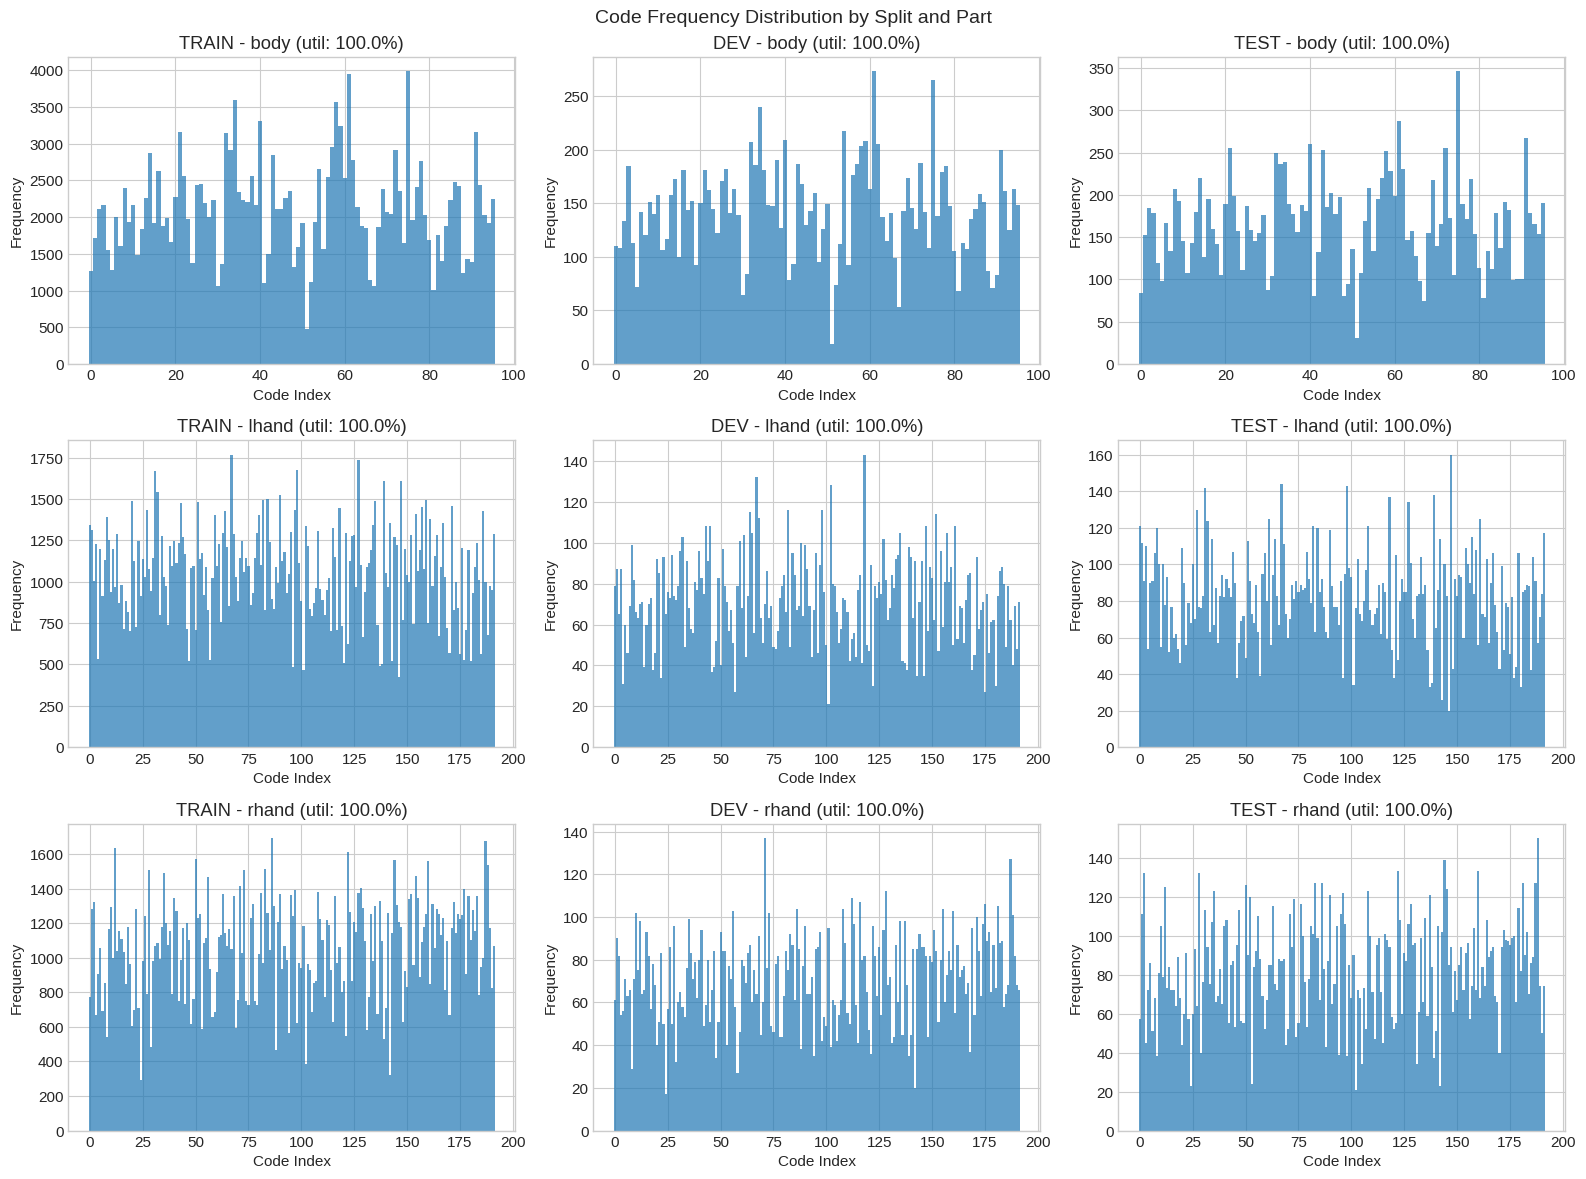

Saved: code_frequency.png


In [9]:
# Visualize code frequency distribution
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for col, split in enumerate(['train', 'dev', 'test']):
    for row, (part, size) in enumerate([('body', BODY_CODEBOOK_SIZE), 
                                         ('lhand', LHAND_CODEBOOK_SIZE), 
                                         ('rhand', RHAND_CODEBOOK_SIZE)]):
        ax = axes[row, col]
        u = utilization[split][part]
        
        if u:
            freqs = u['frequencies']
            ax.bar(range(len(freqs)), freqs, width=1.0, alpha=0.7)
            ax.set_xlabel('Code Index')
            ax.set_ylabel('Frequency')
            ax.set_title(f'{split.upper()} - {part} (util: {u["utilization_rate"]:.1f}%)')
            
            # Mark dead codes in red
            dead_mask = freqs == 0
            if dead_mask.any():
                ylim = ax.get_ylim()[1]
                ax.bar(np.where(dead_mask)[0], [ylim*0.01]*dead_mask.sum(), 
                       width=1.0, color='red', alpha=0.5)

plt.suptitle('Code Frequency Distribution by Split and Part', fontsize=14)
plt.tight_layout()
plt.savefig('code_frequency.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: code_frequency.png")

In [10]:
# Top-10 most frequent codes
print("=" * 60)
print("Top-10 Most Frequent Codes (Train)")
print("=" * 60)

for part in ['body', 'lhand', 'rhand']:
    u = utilization['train'][part]
    if u:
        print(f"\n{part.upper()}:")
        total = u['total_tokens']
        for code, count in u['top_10_codes']:
            pct = count / total * 100
            print(f"  Code {code:3d}: {count:6d} ({pct:5.2f}%)")

Top-10 Most Frequent Codes (Train)

BODY:
  Code  75:   3986 ( 1.95%)
  Code  61:   3947 ( 1.93%)
  Code  34:   3601 ( 1.77%)
  Code  58:   3571 ( 1.75%)
  Code  40:   3310 ( 1.62%)
  Code  59:   3249 ( 1.59%)
  Code  91:   3167 ( 1.55%)
  Code  21:   3156 ( 1.55%)
  Code  32:   3145 ( 1.54%)
  Code  57:   2959 ( 1.45%)

LHAND:
  Code  67:   1767 ( 0.87%)
  Code 127:   1738 ( 0.85%)
  Code  98:   1674 ( 0.82%)
  Code  31:   1669 ( 0.82%)
  Code 139:   1609 ( 0.79%)
  Code 147:   1609 ( 0.79%)
  Code  32:   1540 ( 0.75%)
  Code  90:   1522 ( 0.75%)
  Code  84:   1502 ( 0.74%)
  Code  82:   1495 ( 0.73%)

RHAND:
  Code  86:   1693 ( 0.83%)
  Code 187:   1675 ( 0.82%)
  Code  12:   1638 ( 0.80%)
  Code 122:   1615 ( 0.79%)
  Code  50:   1570 ( 0.77%)
  Code 144:   1568 ( 0.77%)
  Code 160:   1561 ( 0.77%)
  Code 188:   1535 ( 0.75%)
  Code  83:   1517 ( 0.74%)
  Code  28:   1511 ( 0.74%)


In [11]:
# Dead codes analysis
print("=" * 60)
print("Dead Codes Analysis")
print("=" * 60)

for split in ['train', 'dev', 'test']:
    print(f"\n{split.upper()}:")
    for part in ['body', 'lhand', 'rhand']:
        u = utilization[split][part]
        if u and u['num_dead'] > 0:
            dead_sample = u['dead_codes'][:10]
            more = '...' if u['num_dead'] > 10 else ''
            print(f"  {part}: {u['num_dead']} dead codes - {dead_sample}{more}")
        elif u:
            print(f"  {part}: No dead codes (100% utilization)")

Dead Codes Analysis

TRAIN:
  body: No dead codes (100% utilization)
  lhand: No dead codes (100% utilization)
  rhand: No dead codes (100% utilization)

DEV:
  body: No dead codes (100% utilization)
  lhand: No dead codes (100% utilization)
  rhand: No dead codes (100% utilization)

TEST:
  body: No dead codes (100% utilization)
  lhand: No dead codes (100% utilization)
  rhand: No dead codes (100% utilization)


## 4. Split 간 분포 유사성 분석

Train/Dev/Test 간에 code 분포가 유사해야 일반화가 잘 됩니다.

In [12]:
def compute_distribution_similarity(data1, data2, part, codebook_size):
    """
    Compute distribution similarity between two splits.
    """
    if not data1 or not data2:
        return None
    
    # Get code distributions
    codes1 = np.concatenate([d[part] for d in data1])
    codes2 = np.concatenate([d[part] for d in data2])
    
    # Count frequencies
    counts1 = np.array([np.sum(codes1 == i) for i in range(codebook_size)])
    counts2 = np.array([np.sum(codes2 == i) for i in range(codebook_size)])
    
    # Normalize to probabilities
    p1 = (counts1 + 1e-10) / (counts1.sum() + 1e-10 * codebook_size)
    p2 = (counts2 + 1e-10) / (counts2.sum() + 1e-10 * codebook_size)
    
    # KL divergence (asymmetric)
    kl_div = entropy(p1, p2)
    
    # JS divergence (symmetric)
    js_div = jensenshannon(p1, p2)
    
    # Code overlap
    used1 = set(np.unique(codes1))
    used2 = set(np.unique(codes2))
    overlap = len(used1 & used2)
    union = len(used1 | used2)
    jaccard = overlap / union if union > 0 else 0
    
    return {
        'kl_divergence': kl_div,
        'js_divergence': js_div,
        'jaccard_similarity': jaccard,
        'overlap_codes': overlap,
        'union_codes': union,
        'only_in_1': len(used1 - used2),
        'only_in_2': len(used2 - used1),
    }

# Compute similarities
similarity_rows = []
for part, size in [('body', BODY_CODEBOOK_SIZE), ('lhand', LHAND_CODEBOOK_SIZE), ('rhand', RHAND_CODEBOOK_SIZE)]:
    for name1, name2, data1, data2 in [
        ('train', 'dev', train_data, dev_data),
        ('train', 'test', train_data, test_data),
        ('dev', 'test', dev_data, test_data),
    ]:
        sim = compute_distribution_similarity(data1, data2, part, size)
        if sim:
            similarity_rows.append({
                'Part': part,
                'Split1': name1,
                'Split2': name2,
                'JS Divergence': sim['js_divergence'],
                'KL Divergence': sim['kl_divergence'],
                'Jaccard Sim.': sim['jaccard_similarity'],
                'Overlap': sim['overlap_codes'],
                'Only in S1': sim['only_in_1'],
                'Only in S2': sim['only_in_2'],
            })

sim_df = pd.DataFrame(similarity_rows)
print("=" * 80)
print("Distribution Similarity Between Splits")
print("(Lower JS divergence = more similar, Higher Jaccard = more overlap)")
print("=" * 80)
print(sim_df.round(4).to_string())

Distribution Similarity Between Splits
(Lower JS divergence = more similar, Higher Jaccard = more overlap)
    Part Split1 Split2  JS Divergence  KL Divergence  Jaccard Sim.  Overlap  Only in S1  Only in S2
0   body  train    dev         0.0389         0.0061           1.0       96           0           0
1   body  train   test         0.0367         0.0054           1.0       96           0           0
2   body    dev   test         0.0518         0.0109           1.0       96           0           0
3  lhand  train    dev         0.0566         0.0128           1.0      192           0           0
4  lhand  train   test         0.0493         0.0098           1.0      192           0           0
5  lhand    dev   test         0.0757         0.0233           1.0      192           0           0
6  rhand  train    dev         0.0472         0.0089           1.0      192           0           0
7  rhand  train   test         0.0479         0.0093           1.0      192           0      

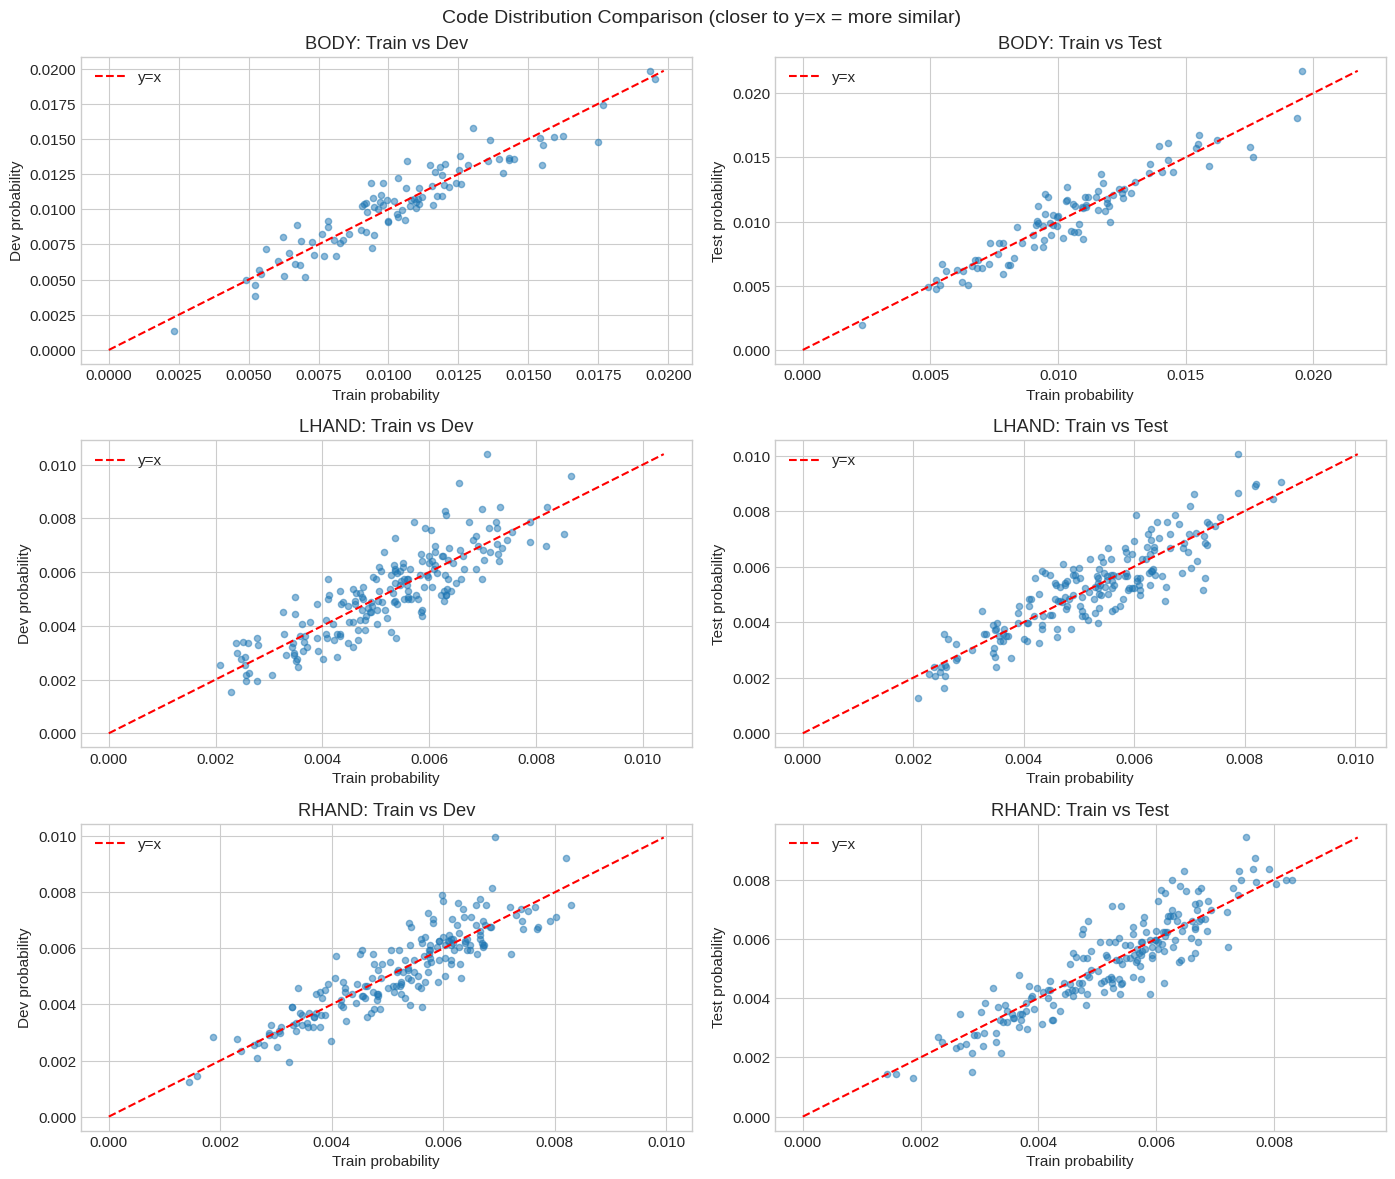

Saved: distribution_comparison.png


In [13]:
# Visualize distribution comparison (Train vs Dev/Test)
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for row, (part, size) in enumerate([('body', BODY_CODEBOOK_SIZE), 
                                     ('lhand', LHAND_CODEBOOK_SIZE), 
                                     ('rhand', RHAND_CODEBOOK_SIZE)]):
    # Train vs Dev
    ax = axes[row, 0]
    if train_data and dev_data:
        train_codes = np.concatenate([d[part] for d in train_data])
        dev_codes = np.concatenate([d[part] for d in dev_data])
        
        train_freq = np.array([np.sum(train_codes == i) for i in range(size)])
        dev_freq = np.array([np.sum(dev_codes == i) for i in range(size)])
        
        train_prob = train_freq / train_freq.sum()
        dev_prob = dev_freq / dev_freq.sum()
        
        ax.scatter(train_prob, dev_prob, alpha=0.5, s=20)
        max_val = max(train_prob.max(), dev_prob.max())
        ax.plot([0, max_val], [0, max_val], 'r--', label='y=x')
        ax.set_xlabel('Train probability')
        ax.set_ylabel('Dev probability')
        ax.set_title(f'{part.upper()}: Train vs Dev')
        ax.legend()
    
    # Train vs Test
    ax = axes[row, 1]
    if train_data and test_data:
        test_codes = np.concatenate([d[part] for d in test_data])
        
        test_freq = np.array([np.sum(test_codes == i) for i in range(size)])
        test_prob = test_freq / test_freq.sum()
        
        ax.scatter(train_prob, test_prob, alpha=0.5, s=20)
        max_val = max(train_prob.max(), test_prob.max())
        ax.plot([0, max_val], [0, max_val], 'r--', label='y=x')
        ax.set_xlabel('Train probability')
        ax.set_ylabel('Test probability')
        ax.set_title(f'{part.upper()}: Train vs Test')
        ax.legend()

plt.suptitle('Code Distribution Comparison (closer to y=x = more similar)', fontsize=14)
plt.tight_layout()
plt.savefig('distribution_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: distribution_comparison.png")

## 5. 시퀀스 패턴 분석

In [14]:
def analyze_sequence_patterns(data, part):
    if not data:
        return None
    
    bigram_counter = Counter()
    repetition_counts = []
    total_transitions = 0
    same_transitions = 0
    
    for d in data:
        codes = d[part]
        for i in range(len(codes) - 1):
            bigram = (codes[i], codes[i+1])
            bigram_counter[bigram] += 1
            total_transitions += 1
            if codes[i] == codes[i+1]:
                same_transitions += 1
        
        rep_count = 0
        for i in range(1, len(codes)):
            if codes[i] == codes[i-1]:
                rep_count += 1
        repetition_counts.append(rep_count / len(codes) if len(codes) > 0 else 0)
    
    return {
        'top_bigrams': bigram_counter.most_common(20),
        'num_unique_bigrams': len(bigram_counter),
        'total_transitions': total_transitions,
        'repetition_rate': same_transitions / total_transitions if total_transitions > 0 else 0,
        'avg_repetition_per_seq': np.mean(repetition_counts),
        'bigram_counter': bigram_counter,
    }

patterns = {}
for split_name, data in [('train', train_data), ('dev', dev_data), ('test', test_data)]:
    patterns[split_name] = {}
    for part in ['body', 'lhand', 'rhand']:
        patterns[split_name][part] = analyze_sequence_patterns(data, part)

In [15]:
# Pattern summary
pattern_rows = []
for split in ['train', 'dev', 'test']:
    for part in ['body', 'lhand', 'rhand']:
        p = patterns[split][part]
        if p:
            pattern_rows.append({
                'Split': split,
                'Part': part,
                'Unique Bigrams': p['num_unique_bigrams'],
                'Repetition Rate (%)': p['repetition_rate'] * 100,
                'Avg Rep. per Seq (%)': p['avg_repetition_per_seq'] * 100,
            })

pattern_df = pd.DataFrame(pattern_rows)
print("=" * 70)
print("Sequence Pattern Analysis")
print("=" * 70)
print(pattern_df.round(2).to_string())

Sequence Pattern Analysis
   Split   Part  Unique Bigrams  Repetition Rate (%)  Avg Rep. per Seq (%)
0  train   body            8971                 9.53                  9.04
1  train  lhand           30611                 6.22                  5.90
2  train  rhand           31870                 4.42                  4.14
3    dev   body            5397                 9.98                  9.57
4    dev  lhand            8975                 6.31                  5.85
5    dev  rhand            9437                 4.34                  4.16
6   test   body            5622                 9.24                  8.43
7   test  lhand            9861                 6.49                  6.27
8   test  rhand           10583                 4.09                  3.80


## 6. 종합 리포트

In [16]:
print("=" * 80)
print("                    MOTION CODE ANALYSIS SUMMARY")
print("=" * 80)

print("\n1. DATA OVERVIEW")
print("-" * 40)
for data, name in [(train_data, 'Train'), (dev_data, 'Dev'), (test_data, 'Test')]:
    if data:
        lengths = [d['length'] for d in data]
        print(f"  {name}: {len(data)} samples, avg length {np.mean(lengths):.1f} frames")

print("\n2. CODEBOOK UTILIZATION")
print("-" * 40)
for part, size in [('body', BODY_CODEBOOK_SIZE), ('lhand', LHAND_CODEBOOK_SIZE), ('rhand', RHAND_CODEBOOK_SIZE)]:
    u = utilization['train'][part]
    if u:
        status = "Good" if u['utilization_rate'] > 80 else "Low" if u['utilization_rate'] > 50 else "Poor"
        print(f"  {part:6s}: {u['utilization_rate']:.1f}% utilized ({u['num_used']}/{size}) - {status}")

print("\n3. SPLIT CONSISTENCY (Train vs Test)")
print("-" * 40)
for part in ['body', 'lhand', 'rhand']:
    sim = compute_distribution_similarity(train_data, test_data, part, 
                                         BODY_CODEBOOK_SIZE if part == 'body' else LHAND_CODEBOOK_SIZE)
    if sim:
        status = "Good" if sim['js_divergence'] < 0.1 else "Moderate" if sim['js_divergence'] < 0.2 else "High"
        print(f"  {part:6s}: JS={sim['js_divergence']:.4f}, Jaccard={sim['jaccard_similarity']:.3f} - {status}")

print("\n4. SEQUENCE PATTERNS (Train)")
print("-" * 40)
for part in ['body', 'lhand', 'rhand']:
    p = patterns['train'][part]
    if p:
        status = "High" if p['repetition_rate'] > 0.3 else "Normal"
        print(f"  {part:6s}: {p['repetition_rate']*100:.1f}% repetition rate - {status}")

print("\n" + "=" * 80)
print("RECOMMENDATIONS:")
print("=" * 80)

recommendations = []
for part in ['body', 'lhand', 'rhand']:
    u = utilization['train'][part]
    if u and u['utilization_rate'] < 70:
        recommendations.append(f"- {part} codebook has low utilization ({u['utilization_rate']:.1f}%)")

for part in ['body', 'lhand', 'rhand']:
    p = patterns['train'][part]
    if p and p['repetition_rate'] > 0.4:
        recommendations.append(f"- {part} has high repetition rate ({p['repetition_rate']*100:.1f}%)")

if not recommendations:
    print("No major issues detected. Motion codes look suitable for T2M training!")
else:
    for rec in recommendations:
        print(rec)

                    MOTION CODE ANALYSIS SUMMARY

1. DATA OVERVIEW
----------------------------------------
  Train: 7096 samples, avg length 28.7 frames
  Dev: 519 samples, avg length 26.5 frames
  Test: 642 samples, avg length 24.8 frames

2. CODEBOOK UTILIZATION
----------------------------------------
  body  : 100.0% utilized (96/96) - Good
  lhand : 100.0% utilized (192/192) - Good
  rhand : 100.0% utilized (192/192) - Good

3. SPLIT CONSISTENCY (Train vs Test)
----------------------------------------
  body  : JS=0.0367, Jaccard=1.000 - Good
  lhand : JS=0.0493, Jaccard=1.000 - Good
  rhand : JS=0.0479, Jaccard=1.000 - Good

4. SEQUENCE PATTERNS (Train)
----------------------------------------
  body  : 9.5% repetition rate - Normal
  lhand : 6.2% repetition rate - Normal
  rhand : 4.4% repetition rate - Normal

RECOMMENDATIONS:
No major issues detected. Motion codes look suitable for T2M training!
